In [7]:
import pandas as pd
data = pd.read_csv("bhisma_data.csv")

convergent_cols = [
    "cortisol",
    "cpas",
    "bisq",
    "ses",
    "fci",
    "phq9.score",
    "mors.invasion",
    "mors.warmth",
    "cprs.closeness",
    "cprs.conflict",
    "anthro.waz",
    "anthro.haz",
    "anthro.wfl",
    "anthro.hcz",
    "pmp.daz",
    "maternal.edu",
    "paternal.edu",
    "maternal.muac",
    "rbs.bin.risk",
    "pci.int",
]

data = (
    data.rename(columns={"id": "child_ids"})
    .drop_duplicates(subset="child_ids")
    .assign(
        country=lambda df: df["country"].astype(str),
        child_ids=lambda df: df["child_ids"].astype(str) + "-BL",
    )
    [["child_ids", "country"] + convergent_cols]
)

data.head()


,child_ids,country,cortisol,cpas,bisq,ses,fci,phq9.score,mors.invasion,mors.warmth,...,anthro.waz,anthro.haz,anthro.wfl,anthro.hcz,pmp.daz,maternal.edu,paternal.edu,maternal.muac,rbs.bin.risk,pci.int
0,IN-0003-BL,IN,NaN,0.829047,NaN,-1.100828,0.081612,1.503747,NaN,NaN,...,1.035191,1.846310,-0.275999,0.249022,-0.676677,-1.513419,-1.214618,-1.809783,0.0,NaN
1,IN-0006-BL,IN,NaN,0.431599,NaN,0.689174,0.457766,0.050641,NaN,NaN,...,0.305472,-0.797824,1.221073,-0.811038,-1.801249,0.239936,0.054454,-0.421868,0.0,NaN
2,IN-0007-BL,IN,NaN,0.101850,NaN,-0.745042,1.507111,1.261563,1.776966,0.185820,...,-1.200150,-1.037449,-1.010588,-0.414668,NaN,1.993290,0.054454,-0.678890,0.0,NaN
3,IN-0011-BL,IN,NaN,1.749237,NaN,-0.429187,0.346437,0.535010,NaN,NaN,...,NaN,NaN,NaN,NaN,0.490089,0.239936,-1.214618,-0.267656,0.0,NaN
4,IN-0012-BL,IN,NaN,0.653623,NaN,-0.533899,-2.258632,2.714669,2.333645,-0.338556,...,-0.950752,0.639923,-1.763773,-0.313271,NaN,0.239936,0.054454,0.323493,0.0,NaN


# Convergent Validity: GMDS Scores Predicted from MDAT Latents

This notebook examines **convergent validity** for **GMDS subscale scores predicted from MDAT latent abilities** — i.e., the output of the criterion validity MLP that maps MDAT latent scores to GMDS subscales. It tests whether those predicted GMDS scores correlate with external covariates in theoretically expected directions.

## Motivation

After establishing that MDAT latents can predict GMDS scores with high criterion validity, a natural follow-up question is: do those predicted GMDS scores inherit the construct validity of GMDS itself? If they do, this provides an additional validation layer — the predicted scores behave like real GMDS scores in relation to the external world.

## MDAT subscales analysed

- `fol`: Foundations of Learning
- `langCom`: Language Comprehension
- `eye_hand`: Eye–Hand Coordination
- `soc_per`: Social Perception
- `gross_mot`: Gross Motor

These are the five GMDS subscales predicted by the MLP from MDAT `tot` latent scores.

## Statistical approach

Identical to the DEEP convergent analysis: Pearson r, 95% Fisher-z CI, BH-FDR adjustment, country-stratified and pooled analyses. See `convergent_analysis_of_GMDS_predicted_using_DEEP.ipynb` for full statistical background.

In [8]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ── Load MDAT & merge ────────────────────────────────────────────────────────
mdat = pd.read_csv("mdat_results.csv")
mdat = mdat.drop_duplicates(subset="child_ids").assign(child_ids=lambda df: df["child_ids"].astype(str))
mdat_subscales = ["fol", "langCom", "eye_hand", "soc_per", "gross_mot"]

merged = data.merge(mdat[["child_ids"] + mdat_subscales], on="child_ids", how="inner")
merged["country_group"] = merged["child_ids"].str[:2]

india  = merged[merged["country_group"] == "IN"].copy()
malawi = merged[merged["country_group"] == "MW"].copy()

print(f"Children after merge:  {len(merged):>4}  total")
print(f"  India  (IN):         {len(india):>4}")
print(f"  Malawi (MW):         {len(malawi):>4}")

# ── Readable labels ───────────────────────────────────────────────────────────
convergent_labels = {
    "cortisol":       "Cortisol",
    "cpas":           "CPAS (Attachment)",
    "bisq":           "BISQ (Sleep)",
    "ses":            "SES",
    "fci":            "FCI (Family Care)",
    "phq9.score":     "PHQ-9 (Dep. Sx)",
    "mors.invasion":  "MORS Invasion",
    "mors.warmth":    "MORS Warmth",
    "cprs.closeness": "CPRS Closeness",
    "cprs.conflict":  "CPRS Conflict",
    "anthro.waz":     "WAZ (Wt-for-age)",
    "anthro.haz":     "HAZ (Ht-for-age)",
    "anthro.wfl":     "WFL (Wt-for-len.)",
    "anthro.hcz":     "HCZ (Head Circumf.)",
    "pmp.daz":        "PMP DAZ",
    "maternal.edu":   "Maternal Education",
    "paternal.edu":   "Paternal Education",
    "maternal.muac":  "Maternal MUAC",
    "rbs.bin.risk":   "RBS Risk",
    "pci.int":        "PCI Interaction",
}

mdat_labels = {
    "fol":       "Foundations of Learning",
    "langCom":   "Lang. Comp.",
    "eye_hand":  "Eye–Hand",
    "soc_per":   "Soc. Percep.",
    "gross_mot": "Gross Motor",
}

# ── Variable ordering ─────────────────────────────────────────────────────────
# Anthropometric variables are analysed separately (different nature)
anthro_cols = ["anthro.waz", "anthro.haz", "anthro.wfl", "anthro.hcz"]

pos_convergent_cols = [
    "cpas",           # attachment security → better development
    "fci",            # family care/stimulation → better development
    "mors.warmth",    # maternal warmth → better development
    "cprs.closeness", # parent-child closeness → better development
    "ses",            # socioeconomic resources → better development
    "maternal.edu",   # maternal education → better development
    "paternal.edu",   # paternal education → better development
    "maternal.muac",  # maternal nutrition → better child development
    "pmp.daz",        # developmental score → better development
    "pci.int",        # parent-child interaction quality → better development
]
neg_convergent_cols = [
    "cortisol",       # stress hormone → worse development
    "bisq",           # sleep problems → worse development
    "phq9.score",     # maternal depression → worse development
    "mors.invasion",  # maternal intrusiveness → worse development
    "cprs.conflict",  # parent-child conflict → worse development
    "rbs.bin.risk",   # risk score → worse development
]
convergent_cols_ordered = pos_convergent_cols + neg_convergent_cols
N_POS = len(pos_convergent_cols)   # row index where negative group starts

# ── BH-FDR correction ────────────────────────────────────────────────────────
def bh_fdr(pvals):
    pvals = np.asarray(pvals, dtype=float)
    out   = np.full_like(pvals, np.nan)
    valid = ~np.isnan(pvals)
    idx   = np.where(valid)[0]
    m     = idx.size
    if m == 0:
        return out
    p_sub  = pvals[idx]
    order  = np.argsort(p_sub)
    ranked = np.empty(m); ranked[order] = np.arange(1, m + 1)
    adj    = p_sub * m / ranked
    adj_sorted = adj[order]
    for i in range(m - 2, -1, -1):
        adj_sorted[i] = min(adj_sorted[i], adj_sorted[i + 1])
    adj[order] = adj_sorted
    out[idx] = np.clip(adj, 0, 1)
    return out

# ── Pearson r + 95% CI (Fisher z) + BH-FDR ──────────────────────────────────
def pearson_table(df, row_vars, col_vars, min_n=8):
    r_mat  = np.full((len(row_vars), len(col_vars)), np.nan)
    p_mat  = np.full((len(row_vars), len(col_vars)), np.nan)
    lo_mat = np.full((len(row_vars), len(col_vars)), np.nan)
    hi_mat = np.full((len(row_vars), len(col_vars)), np.nan)
    n_mat  = np.full((len(row_vars), len(col_vars)), np.nan)
    for i, rv in enumerate(row_vars):
        for j, cv in enumerate(col_vars):
            tmp = df[[rv, cv]].dropna()
            n   = len(tmp)
            n_mat[i, j] = n
            if n >= min_n:
                res = stats.pearsonr(tmp[rv], tmp[cv])
                r_mat[i, j]  = res.statistic
                p_mat[i, j]  = res.pvalue
                ci = res.confidence_interval(confidence_level=0.95)
                lo_mat[i, j] = ci.low
                hi_mat[i, j] = ci.high
    pa_flat = bh_fdr(p_mat.flatten())
    pa_mat  = pa_flat.reshape(p_mat.shape)
    kw = dict(index=row_vars, columns=col_vars)
    return (
        pd.DataFrame(r_mat,  **kw), pd.DataFrame(p_mat,  **kw),
        pd.DataFrame(pa_mat, **kw), pd.DataFrame(lo_mat, **kw),
        pd.DataFrame(hi_mat, **kw), pd.DataFrame(n_mat,  **kw),
    )

# ── Significance stars ────────────────────────────────────────────────────────
def stars(p):
    if pd.isna(p): return ""
    if p < 0.001:  return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    if p < 0.10:   return "·"
    return ""

# ── Formatted table: r* [lo, hi] ─────────────────────────────────────────────
def make_display_table(r_df, pa_df, lo_df, hi_df):
    rows = [convergent_labels.get(r, r) for r in r_df.index]
    cols = [mdat_labels.get(c, c)       for c in r_df.columns]
    out  = pd.DataFrame(index=rows, columns=cols)
    for i, rv in enumerate(r_df.index):
        for j, cv in enumerate(r_df.columns):
            r  = r_df.iloc[i, j];  p  = pa_df.iloc[i, j]
            lo = lo_df.iloc[i, j]; hi = hi_df.iloc[i, j]
            if np.isnan(r):
                out.iloc[i, j] = "—"
            else:
                out.iloc[i, j] = f"{r:+.2f}{stars(p):3} [{lo:+.2f}, {hi:+.2f}]"
    return out

# ── Heatmap — CIs shown inside cells; optional +/− separator ─────────────────
def draw_heatmap(r_df, pa_df, lo_df, hi_df, n_df, title, ax, show_separator=True):
    r_plot = r_df.copy().astype(float)
    r_plot.index   = [convergent_labels.get(r, r) for r in r_df.index]
    r_plot.columns = [mdat_labels.get(c, c)       for c in r_df.columns]

    annot = pd.DataFrame("", index=r_plot.index, columns=r_plot.columns)
    for i, rv in enumerate(r_df.index):
        for j, cv in enumerate(r_df.columns):
            val = r_df.iloc[i, j];  p  = pa_df.iloc[i, j]
            lo  = lo_df.iloc[i, j]; hi = hi_df.iloc[i, j]
            n   = n_df.iloc[i, j]
            rl  = convergent_labels.get(rv, rv)
            cl  = mdat_labels.get(cv, cv)
            if not np.isnan(val):
                s     = stars(p)
                line1 = f"{val:+.2f}{s}"
                line2 = f"[{lo:+.2f},{hi:+.2f}]" if not np.isnan(lo) else ""
                line3 = f"n={int(n)}" if not np.isnan(n) else ""
                parts = [line1] + ([line2] if line2 else []) + ([line3] if line3 else [])
                annot.loc[rl, cl] = "\n".join(parts)

    sns.heatmap(
        r_plot, ax=ax,
        annot=annot, fmt="",
        center=0, vmin=-1, vmax=1,
        cmap="RdBu_r",
        linewidths=0.5, linecolor="#e0e0e0",
        cbar_kws={"shrink": 0.55, "label": "Pearson r"},
        annot_kws={"size": 6},
    )

    if show_separator:
        n_rows = len(r_df)
        ax.hlines(N_POS, xmin=0, xmax=len(r_df.columns),
                  colors="#111", linewidths=2.5, linestyles="--")
        blend = mtransforms.blended_transform_factory(ax.transAxes, ax.transData)
        ax.text(-0.01, N_POS / 2.0,
                "Expected\n(+)", ha="right", va="center",
                fontsize=7.5, color="#444", style="italic",
                transform=blend, clip_on=False)
        ax.text(-0.01, N_POS + (n_rows - N_POS) / 2.0,
                "Expected\n(−)", ha="right", va="center",
                fontsize=7.5, color="#444", style="italic",
                transform=blend, clip_on=False)

    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("MDAT Subscale", fontsize=10, labelpad=6)
    ax.tick_params(axis="x", rotation=30, labelsize=9)
    ax.tick_params(axis="y", rotation=0,  labelsize=8)


Children after merge:  1967  total
  India  (IN):          944
  Malawi (MW):         1023


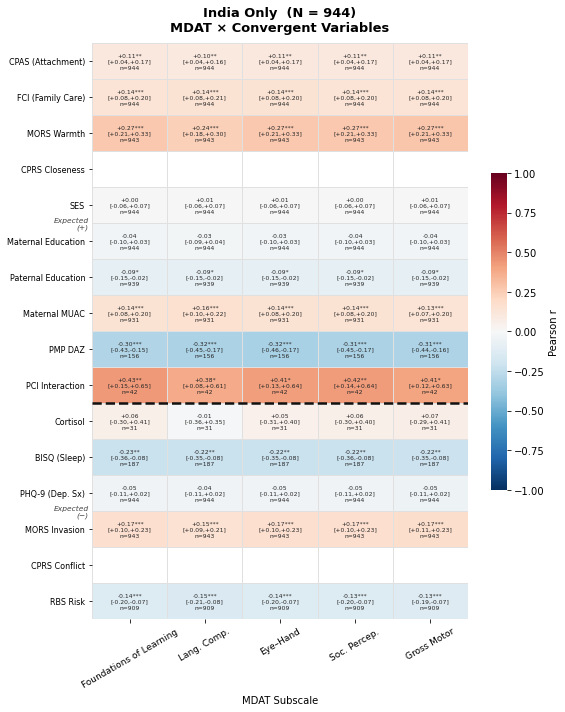


── India: Pearson r  95% CI  (BH-FDR adjusted p)  ·p<.10  *p<.05  **p<.01  ***p<.001 ──



,Foundations of Learning,Lang. Comp.,Eye–Hand,Soc. Percep.,Gross Motor
CPAS (Attachment),"+0.11** [+0.04, +0.17]","+0.10** [+0.04, +0.16]","+0.11** [+0.04, +0.17]","+0.11** [+0.04, +0.17]","+0.11** [+0.04, +0.17]"
FCI (Family Care),"+0.14*** [+0.08, +0.20]","+0.14*** [+0.08, +0.21]","+0.14*** [+0.08, +0.20]","+0.14*** [+0.08, +0.20]","+0.14*** [+0.08, +0.20]"
MORS Warmth,"+0.27*** [+0.21, +0.33]","+0.24*** [+0.18, +0.30]","+0.27*** [+0.21, +0.33]","+0.27*** [+0.21, +0.33]","+0.27*** [+0.21, +0.33]"
CPRS Closeness,—,—,—,—,—
SES,"+0.00 [-0.06, +0.07]","+0.01 [-0.06, +0.07]","+0.01 [-0.06, +0.07]","+0.00 [-0.06, +0.07]","+0.01 [-0.06, +0.07]"
Maternal Education,"-0.04 [-0.10, +0.03]","-0.03 [-0.09, +0.04]","-0.03 [-0.10, +0.03]","-0.04 [-0.10, +0.03]","-0.04 [-0.10, +0.03]"
Paternal Education,"-0.09* [-0.15, -0.02]","-0.09* [-0.15, -0.02]","-0.09* [-0.15, -0.02]","-0.09* [-0.15, -0.02]","-0.09* [-0.15, -0.02]"
Maternal MUAC,"+0.14*** [+0.08, +0.20]","+0.16*** [+0.10, +0.22]","+0.14*** [+0.08, +0.20]","+0.14*** [+0.08, +0.20]","+0.13*** [+0.07, +0.20]"
PMP DAZ,"-0.30*** [-0.43, -0.15]","-0.32*** [-0.45, -0.17]","-0.32*** [-0.46, -0.17]","-0.31*** [-0.45, -0.17]","-0.31*** [-0.44, -0.16]"
PCI Interaction,"+0.43** [+0.15, +0.65]","+0.38* [+0.08, +0.61]","+0.41* [+0.13, +0.64]","+0.42** [+0.14, +0.64]","+0.41* [+0.12, +0.63]"



────────────────────────────────────────────────────────────
  India — Anthropometric Variables
────────────────────────────────────────────────────────────


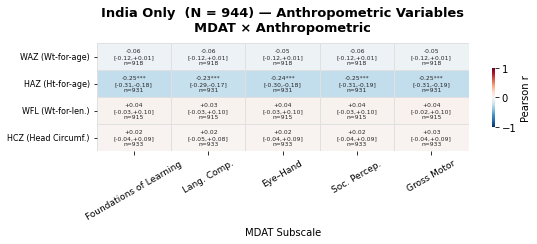


── India (Anthropometric): Pearson r  95% CI  (BH-FDR adjusted p) ──



,Foundations of Learning,Lang. Comp.,Eye–Hand,Soc. Percep.,Gross Motor
WAZ (Wt-for-age),"-0.06 [-0.12, +0.01]","-0.06 [-0.12, +0.01]","-0.05 [-0.12, +0.01]","-0.06 [-0.12, +0.01]","-0.05 [-0.12, +0.01]"
HAZ (Ht-for-age),"-0.25*** [-0.31, -0.18]","-0.23*** [-0.29, -0.17]","-0.24*** [-0.30, -0.18]","-0.25*** [-0.31, -0.19]","-0.25*** [-0.31, -0.19]"
WFL (Wt-for-len.),"+0.04 [-0.03, +0.10]","+0.03 [-0.03, +0.10]","+0.04 [-0.03, +0.10]","+0.04 [-0.03, +0.10]","+0.04 [-0.02, +0.10]"
HCZ (Head Circumf.),"+0.02 [-0.04, +0.09]","+0.02 [-0.05, +0.08]","+0.02 [-0.04, +0.09]","+0.02 [-0.04, +0.09]","+0.03 [-0.04, +0.09]"


In [9]:

# ═══════════════════════════════════════════════════════════
#  ANALYSIS 1 — INDIA ONLY
# ═══════════════════════════════════════════════════════════

# ── Main convergent variables ─────────────────────────────
r_in, p_in, pa_in, lo_in, hi_in, n_in = pearson_table(india, convergent_cols_ordered, mdat_subscales)

fig, ax = plt.subplots(figsize=(8, 10))
draw_heatmap(r_in, pa_in, lo_in, hi_in, n_in,
             f"India Only  (N = {len(india)})\nMDAT × Convergent Variables", ax)
plt.tight_layout()
plt.savefig("heatmap_india.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── India: Pearson r  95% CI  (BH-FDR adjusted p)  ·p<.10  *p<.05  **p<.01  ***p<.001 ──\n")
display(make_display_table(r_in, pa_in, lo_in, hi_in))

# ── Anthropometric variables (separate analysis) ──────────
print("\n" + "─" * 60)
print("  India — Anthropometric Variables")
print("─" * 60)
r_in_a, p_in_a, pa_in_a, lo_in_a, hi_in_a, n_in_a = pearson_table(india, anthro_cols, mdat_subscales)

fig, ax = plt.subplots(figsize=(8, 3.5))
draw_heatmap(r_in_a, pa_in_a, lo_in_a, hi_in_a, n_in_a,
             f"India Only  (N = {len(india)}) — Anthropometric Variables\nMDAT × Anthropometric", ax,
             show_separator=False)
plt.tight_layout()
plt.savefig("heatmap_india_anthro.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── India (Anthropometric): Pearson r  95% CI  (BH-FDR adjusted p) ──\n")
display(make_display_table(r_in_a, pa_in_a, lo_in_a, hi_in_a))


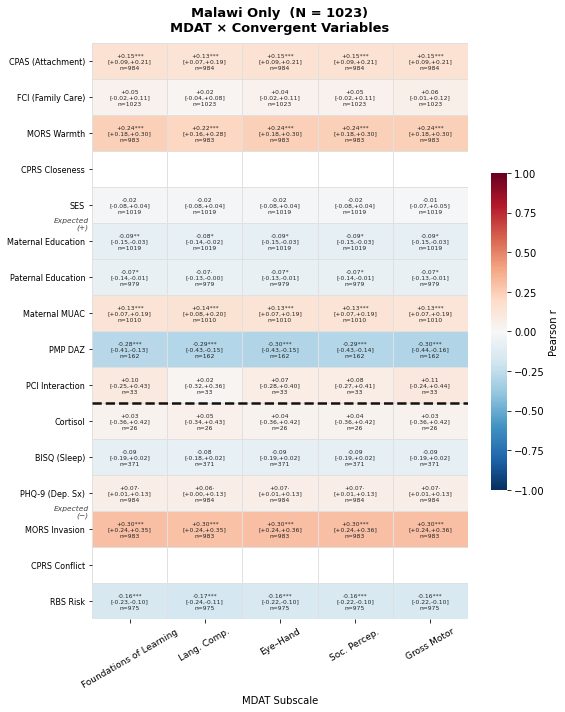


── Malawi: Pearson r  95% CI  (BH-FDR adjusted p)  ·p<.10  *p<.05  **p<.01  ***p<.001 ──



,Foundations of Learning,Lang. Comp.,Eye–Hand,Soc. Percep.,Gross Motor
CPAS (Attachment),"+0.15*** [+0.09, +0.21]","+0.13*** [+0.07, +0.19]","+0.15*** [+0.09, +0.21]","+0.15*** [+0.09, +0.21]","+0.15*** [+0.09, +0.21]"
FCI (Family Care),"+0.05 [-0.02, +0.11]","+0.02 [-0.04, +0.08]","+0.04 [-0.02, +0.11]","+0.05 [-0.02, +0.11]","+0.06 [-0.01, +0.12]"
MORS Warmth,"+0.24*** [+0.18, +0.30]","+0.22*** [+0.16, +0.28]","+0.24*** [+0.18, +0.30]","+0.24*** [+0.18, +0.30]","+0.24*** [+0.18, +0.30]"
CPRS Closeness,—,—,—,—,—
SES,"-0.02 [-0.08, +0.04]","-0.02 [-0.08, +0.04]","-0.02 [-0.08, +0.04]","-0.02 [-0.08, +0.04]","-0.01 [-0.07, +0.05]"
Maternal Education,"-0.09** [-0.15, -0.03]","-0.08* [-0.14, -0.02]","-0.09* [-0.15, -0.03]","-0.09* [-0.15, -0.03]","-0.09* [-0.15, -0.03]"
Paternal Education,"-0.07* [-0.14, -0.01]","-0.07· [-0.13, -0.00]","-0.07* [-0.13, -0.01]","-0.07* [-0.14, -0.01]","-0.07* [-0.13, -0.01]"
Maternal MUAC,"+0.13*** [+0.07, +0.19]","+0.14*** [+0.08, +0.20]","+0.13*** [+0.07, +0.19]","+0.13*** [+0.07, +0.19]","+0.13*** [+0.07, +0.19]"
PMP DAZ,"-0.28*** [-0.41, -0.13]","-0.29*** [-0.43, -0.15]","-0.30*** [-0.43, -0.15]","-0.29*** [-0.43, -0.14]","-0.30*** [-0.44, -0.16]"
PCI Interaction,"+0.10 [-0.25, +0.43]","+0.02 [-0.32, +0.36]","+0.07 [-0.28, +0.40]","+0.08 [-0.27, +0.41]","+0.11 [-0.24, +0.44]"



────────────────────────────────────────────────────────────
  Malawi — Anthropometric Variables
────────────────────────────────────────────────────────────


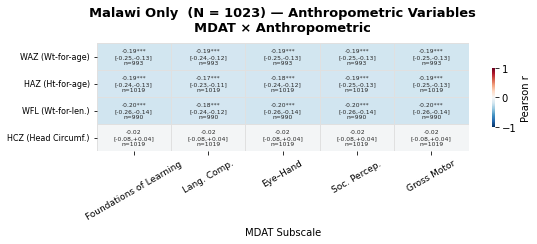


── Malawi (Anthropometric): Pearson r  95% CI  (BH-FDR adjusted p) ──



,Foundations of Learning,Lang. Comp.,Eye–Hand,Soc. Percep.,Gross Motor
WAZ (Wt-for-age),"-0.19*** [-0.25, -0.13]","-0.19*** [-0.24, -0.12]","-0.19*** [-0.25, -0.13]","-0.19*** [-0.25, -0.13]","-0.19*** [-0.25, -0.13]"
HAZ (Ht-for-age),"-0.19*** [-0.24, -0.13]","-0.17*** [-0.23, -0.11]","-0.18*** [-0.24, -0.12]","-0.19*** [-0.25, -0.13]","-0.19*** [-0.25, -0.13]"
WFL (Wt-for-len.),"-0.20*** [-0.26, -0.14]","-0.18*** [-0.24, -0.12]","-0.20*** [-0.26, -0.14]","-0.20*** [-0.26, -0.14]","-0.20*** [-0.26, -0.14]"
HCZ (Head Circumf.),"-0.02 [-0.08, +0.04]","-0.02 [-0.08, +0.04]","-0.02 [-0.08, +0.04]","-0.02 [-0.08, +0.04]","-0.02 [-0.08, +0.04]"


In [10]:

# ═══════════════════════════════════════════════════════════
#  ANALYSIS 2 — MALAWI ONLY
# ═══════════════════════════════════════════════════════════

# ── Main convergent variables ─────────────────────────────
r_mw, p_mw, pa_mw, lo_mw, hi_mw, n_mw = pearson_table(malawi, convergent_cols_ordered, mdat_subscales)

fig, ax = plt.subplots(figsize=(8, 10))
draw_heatmap(r_mw, pa_mw, lo_mw, hi_mw, n_mw,
             f"Malawi Only  (N = {len(malawi)})\nMDAT × Convergent Variables", ax)
plt.tight_layout()
plt.savefig("heatmap_malawi.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── Malawi: Pearson r  95% CI  (BH-FDR adjusted p)  ·p<.10  *p<.05  **p<.01  ***p<.001 ──\n")
display(make_display_table(r_mw, pa_mw, lo_mw, hi_mw))

# ── Anthropometric variables (separate analysis) ──────────
print("\n" + "─" * 60)
print("  Malawi — Anthropometric Variables")
print("─" * 60)
r_mw_a, p_mw_a, pa_mw_a, lo_mw_a, hi_mw_a, n_mw_a = pearson_table(malawi, anthro_cols, mdat_subscales)

fig, ax = plt.subplots(figsize=(8, 3.5))
draw_heatmap(r_mw_a, pa_mw_a, lo_mw_a, hi_mw_a, n_mw_a,
             f"Malawi Only  (N = {len(malawi)}) — Anthropometric Variables\nMDAT × Anthropometric", ax,
             show_separator=False)
plt.tight_layout()
plt.savefig("heatmap_malawi_anthro.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── Malawi (Anthropometric): Pearson r  95% CI  (BH-FDR adjusted p) ──\n")
display(make_display_table(r_mw_a, pa_mw_a, lo_mw_a, hi_mw_a))


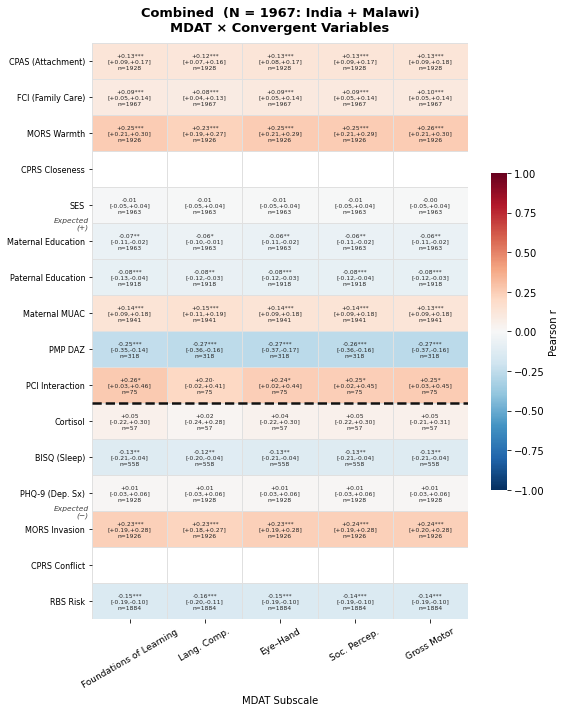


── Combined: Pearson r  95% CI  (BH-FDR adjusted p)  ·p<.10  *p<.05  **p<.01  ***p<.001 ──



,Foundations of Learning,Lang. Comp.,Eye–Hand,Soc. Percep.,Gross Motor
CPAS (Attachment),"+0.13*** [+0.09, +0.17]","+0.12*** [+0.07, +0.16]","+0.13*** [+0.08, +0.17]","+0.13*** [+0.09, +0.17]","+0.13*** [+0.09, +0.18]"
FCI (Family Care),"+0.09*** [+0.05, +0.14]","+0.08*** [+0.04, +0.13]","+0.09*** [+0.05, +0.14]","+0.09*** [+0.05, +0.14]","+0.10*** [+0.05, +0.14]"
MORS Warmth,"+0.25*** [+0.21, +0.30]","+0.23*** [+0.19, +0.27]","+0.25*** [+0.21, +0.29]","+0.25*** [+0.21, +0.29]","+0.26*** [+0.21, +0.30]"
CPRS Closeness,—,—,—,—,—
SES,"-0.01 [-0.05, +0.04]","-0.01 [-0.05, +0.04]","-0.01 [-0.05, +0.04]","-0.01 [-0.05, +0.04]","-0.00 [-0.05, +0.04]"
Maternal Education,"-0.07** [-0.11, -0.02]","-0.06* [-0.10, -0.01]","-0.06** [-0.11, -0.02]","-0.06** [-0.11, -0.02]","-0.06** [-0.11, -0.02]"
Paternal Education,"-0.08*** [-0.13, -0.04]","-0.08** [-0.12, -0.03]","-0.08*** [-0.12, -0.03]","-0.08*** [-0.12, -0.04]","-0.08*** [-0.12, -0.03]"
Maternal MUAC,"+0.14*** [+0.09, +0.18]","+0.15*** [+0.11, +0.19]","+0.14*** [+0.09, +0.18]","+0.14*** [+0.09, +0.18]","+0.13*** [+0.09, +0.18]"
PMP DAZ,"-0.25*** [-0.35, -0.14]","-0.27*** [-0.36, -0.16]","-0.27*** [-0.37, -0.17]","-0.26*** [-0.36, -0.16]","-0.27*** [-0.37, -0.16]"
PCI Interaction,"+0.26* [+0.03, +0.46]","+0.20· [-0.02, +0.41]","+0.24* [+0.02, +0.44]","+0.25* [+0.02, +0.45]","+0.25* [+0.03, +0.45]"



────────────────────────────────────────────────────────────
  Combined — Anthropometric Variables
────────────────────────────────────────────────────────────


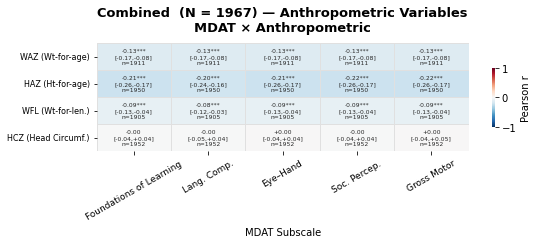


── Combined (Anthropometric): Pearson r  95% CI  (BH-FDR adjusted p) ──



,Foundations of Learning,Lang. Comp.,Eye–Hand,Soc. Percep.,Gross Motor
WAZ (Wt-for-age),"-0.13*** [-0.17, -0.08]","-0.13*** [-0.17, -0.08]","-0.13*** [-0.17, -0.08]","-0.13*** [-0.17, -0.08]","-0.13*** [-0.17, -0.08]"
HAZ (Ht-for-age),"-0.21*** [-0.26, -0.17]","-0.20*** [-0.24, -0.16]","-0.21*** [-0.26, -0.17]","-0.22*** [-0.26, -0.17]","-0.22*** [-0.26, -0.17]"
WFL (Wt-for-len.),"-0.09*** [-0.13, -0.04]","-0.08*** [-0.12, -0.03]","-0.09*** [-0.13, -0.04]","-0.09*** [-0.13, -0.04]","-0.09*** [-0.13, -0.04]"
HCZ (Head Circumf.),"-0.00 [-0.04, +0.04]","-0.00 [-0.05, +0.04]","+0.00 [-0.04, +0.04]","-0.00 [-0.04, +0.04]","+0.00 [-0.04, +0.05]"


In [11]:

# ═══════════════════════════════════════════════════════════
#  ANALYSIS 3 — COMBINED (India + Malawi)
# ═══════════════════════════════════════════════════════════

# ── Main convergent variables ─────────────────────────────
r_all, p_all, pa_all, lo_all, hi_all, n_all = pearson_table(merged, convergent_cols_ordered, mdat_subscales)

fig, ax = plt.subplots(figsize=(8, 10))
draw_heatmap(r_all, pa_all, lo_all, hi_all, n_all,
             f"Combined  (N = {len(merged)}: India + Malawi)\nMDAT × Convergent Variables", ax)
plt.tight_layout()
plt.savefig("heatmap_combined.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── Combined: Pearson r  95% CI  (BH-FDR adjusted p)  ·p<.10  *p<.05  **p<.01  ***p<.001 ──\n")
display(make_display_table(r_all, pa_all, lo_all, hi_all))

# ── Anthropometric variables (separate analysis) ──────────
print("\n" + "─" * 60)
print("  Combined — Anthropometric Variables")
print("─" * 60)
r_all_a, p_all_a, pa_all_a, lo_all_a, hi_all_a, n_all_a = pearson_table(merged, anthro_cols, mdat_subscales)

fig, ax = plt.subplots(figsize=(8, 3.5))
draw_heatmap(r_all_a, pa_all_a, lo_all_a, hi_all_a, n_all_a,
             f"Combined  (N = {len(merged)}) — Anthropometric Variables\nMDAT × Anthropometric", ax,
             show_separator=False)
plt.tight_layout()
plt.savefig("heatmap_combined_anthro.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n── Combined (Anthropometric): Pearson r  95% CI  (BH-FDR adjusted p) ──\n")
display(make_display_table(r_all_a, pa_all_a, lo_all_a, hi_all_a))


In [12]:

# ═══════════════════════════════════════════════════════════
#  EXPORT — save all results to CSV
# ═══════════════════════════════════════════════════════════

def results_to_long(r_df, p_df, pa_df, lo_df, hi_df, n_df, group):
    rows = []
    for rv in r_df.index:
        for cv in r_df.columns:
            r   = r_df.loc[rv, cv]
            p   = p_df.loc[rv, cv]
            pa  = pa_df.loc[rv, cv]
            lo  = lo_df.loc[rv, cv]
            hi  = hi_df.loc[rv, cv]
            n   = n_df.loc[rv, cv]
            rows.append({
                "group":          group,
                "convergent_var": rv,
                "mdat_subscale":  cv,
                "n":              int(n) if not np.isnan(n) else np.nan,
                "r":              round(r,  4) if not np.isnan(r)  else np.nan,
                "ci_low_95":      round(lo, 4) if not np.isnan(lo) else np.nan,
                "ci_high_95":     round(hi, 4) if not np.isnan(hi) else np.nan,
                "p_raw":          round(p,  4) if not np.isnan(p)  else np.nan,
                "p_adj_fdr":      round(pa, 4) if not np.isnan(pa) else np.nan,
                "sig":            stars(pa),
            })
    return pd.DataFrame(rows)

results = pd.concat([
    results_to_long(r_in,  p_in,  pa_in,  lo_in,  hi_in,  n_in,  "India"),
    results_to_long(r_mw,  p_mw,  pa_mw,  lo_mw,  hi_mw,  n_mw,  "Malawi"),
    results_to_long(r_all, p_all, pa_all, lo_all, hi_all, n_all, "Combined"),
], ignore_index=True)

results.to_csv("convergent_correlations.csv", index=False)
print(f"Saved {len(results)} rows  →  convergent_correlations.csv")
print(f"\nColumns: {list(results.columns)}")
display(results.head(10))


Saved 240 rows  →  convergent_correlations.csv

Columns: ['group', 'convergent_var', 'mdat_subscale', 'n', 'r', 'ci_low_95', 'ci_high_95', 'p_raw', 'p_adj_fdr', 'sig']


,group,convergent_var,mdat_subscale,n,r,ci_low_95,ci_high_95,p_raw,p_adj_fdr,sig
0,India,cpas,fol,944,0.1078,0.0443,0.1704,0.0009,0.0020,**
1,India,cpas,langCom,944,0.1006,0.0371,0.1634,0.0020,0.0038,**
2,India,cpas,eye_hand,944,0.1056,0.0421,0.1683,0.0012,0.0024,**
3,India,cpas,soc_per,944,0.1066,0.0430,0.1692,0.0010,0.0022,**
4,India,cpas,gross_mot,944,0.1084,0.0449,0.1710,0.0009,0.0019,**
5,India,fci,fol,944,0.1396,0.0765,0.2016,0.0000,0.0001,***
6,India,fci,langCom,944,0.1440,0.0809,0.2059,0.0000,0.0001,***
7,India,fci,eye_hand,944,0.1414,0.0783,0.2034,0.0000,0.0001,***
8,India,fci,soc_per,944,0.1405,0.0774,0.2025,0.0000,0.0001,***
9,India,fci,gross_mot,944,0.1384,0.0753,0.2005,0.0000,0.0001,***
